# Episode Data Visualization
Laden und visualisieren der CSV-Daten aus 5-16-Epi0.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# CSV laden
csv_path = r'c:\Users\NilsWindows\Desktop\research2.0\data\episFormula\7.3 measured correct drain\5-16-Epi0.csv'
df = pd.read_csv(csv_path)

print(df.head())
print(f"\nDatenform: {df.shape}")
print(f"\nSpalten: {df.columns.tolist()}")

   doy     abstime  time   temp    humi        light  drain  timeToIrri  \
0  136  246.346667     0  11.27   89.71   211.428971   0.01   42.201667   
1  136  256.796667    10  23.26  177.13   481.769509   0.01   31.751667   
2  136  267.250000    20  36.02  262.10   820.805625   0.01   21.298333   
3  136  277.698333    30  49.49  344.56  1238.734629   0.01   10.850000   
4  136  288.548333     0  63.20  425.24  1582.869835   0.59  125.980000   

     reward  terminal  idealIrri   evoCumsum  
0 -0.072727         0        160   21.142897  
1 -0.072727         0        150   48.176951  
2 -0.072727         0        140   82.080563  
3 -0.072727         0        130  123.873463  
4 -0.225532         0        120  158.286984  

Datenform: (77, 12)

Spalten: ['doy', 'abstime', 'time', 'temp', 'humi', 'light', 'drain', 'timeToIrri', 'reward', 'terminal', 'idealIrri', 'evoCumsum']


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\NilsWindows\\Desktop\\research2.0\\plots\\episode_5-16-Epi0_all_metrics.png'

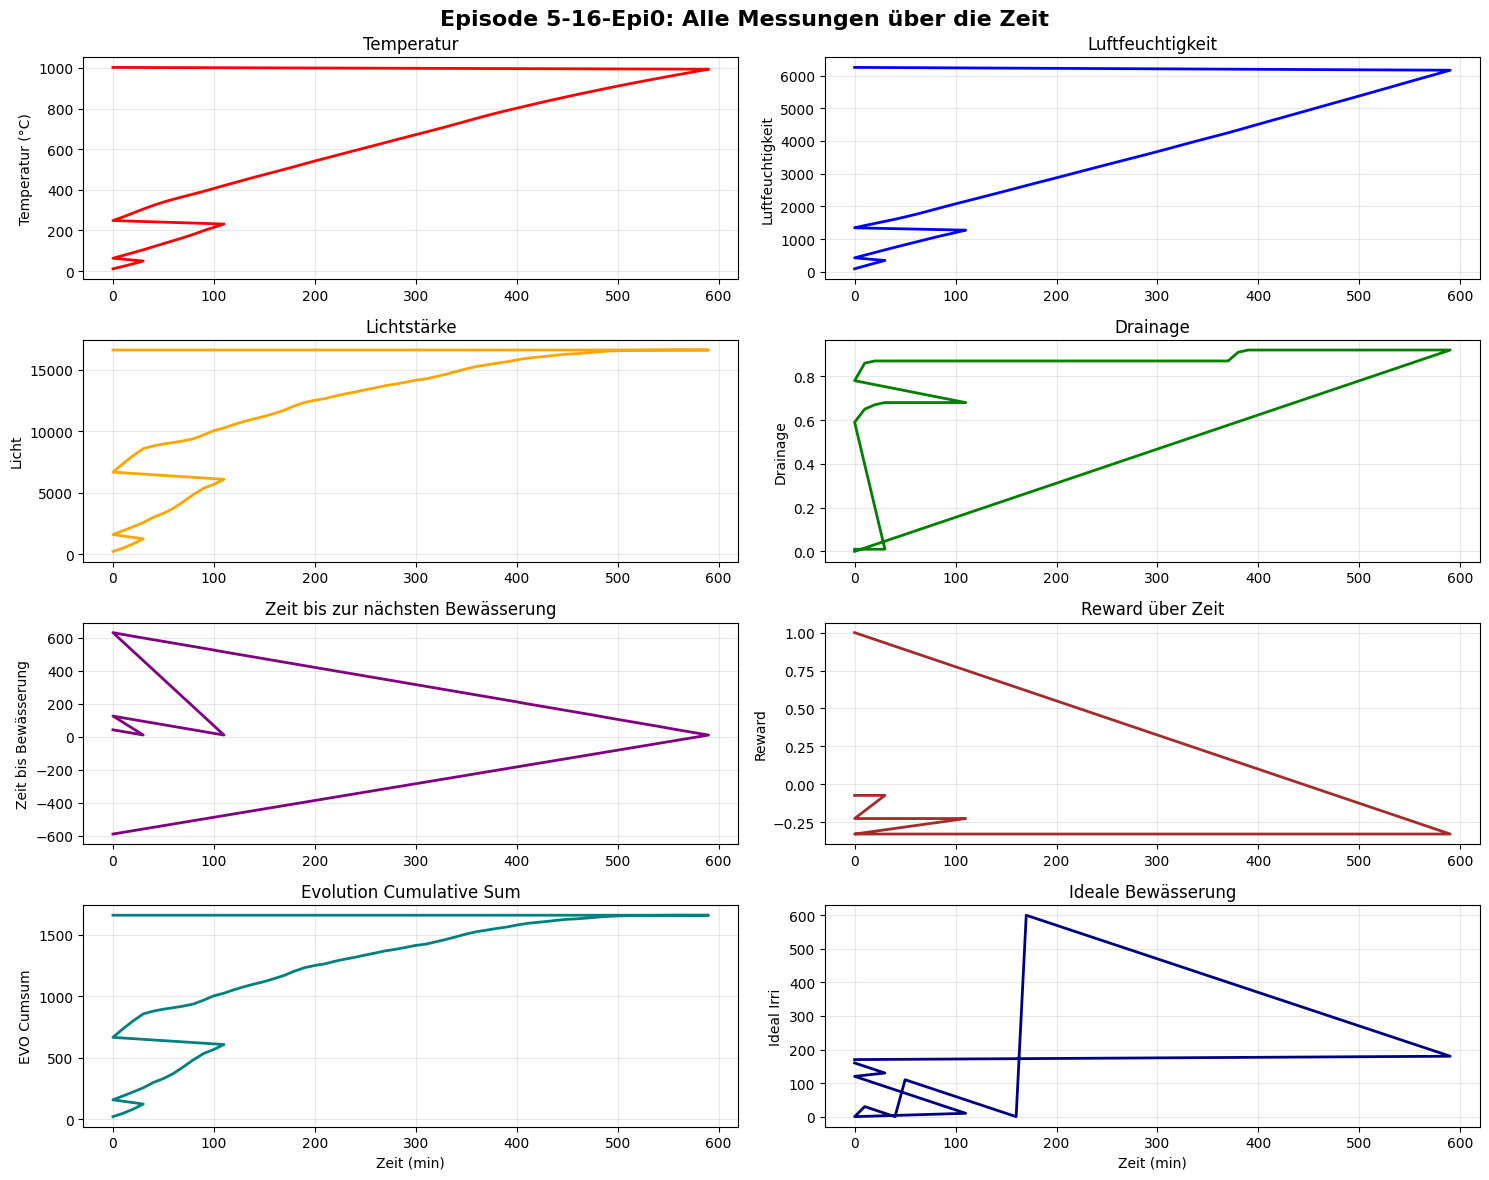

In [2]:
# Erstelle einen umfassenden Plot mit mehreren Subplots
fig, axes = plt.subplots(4, 2, figsize=(15, 12))
fig.suptitle('Episode 5-16-Epi0: Alle Messungen über die Zeit', fontsize=16, fontweight='bold')

# 1. Temperatur
axes[0, 0].plot(df['time'], df['temp'], color='red', linewidth=2)
axes[0, 0].set_ylabel('Temperatur (°C)')
axes[0, 0].set_title('Temperatur')
axes[0, 0].grid(True, alpha=0.3)

# 2. Luftfeuchtigkeit
axes[0, 1].plot(df['time'], df['humi'], color='blue', linewidth=2)
axes[0, 1].set_ylabel('Luftfeuchtigkeit')
axes[0, 1].set_title('Luftfeuchtigkeit')
axes[0, 1].grid(True, alpha=0.3)

# 3. Licht
axes[1, 0].plot(df['time'], df['light'], color='orange', linewidth=2)
axes[1, 0].set_ylabel('Licht')
axes[1, 0].set_title('Lichtstärke')
axes[1, 0].grid(True, alpha=0.3)

# 4. Drainage
axes[1, 1].plot(df['time'], df['drain'], color='green', linewidth=2)
axes[1, 1].set_ylabel('Drainage')
axes[1, 1].set_title('Drainage')
axes[1, 1].grid(True, alpha=0.3)

# 5. Time to Irrigation
axes[2, 0].plot(df['time'], df['timeToIrri'], color='purple', linewidth=2)
axes[2, 0].set_ylabel('Zeit bis Bewässerung')
axes[2, 0].set_title('Zeit bis zur nächsten Bewässerung')
axes[2, 0].grid(True, alpha=0.3)

# 6. Reward
axes[2, 1].plot(df['time'], df['reward'], color='brown', linewidth=2)
axes[2, 1].set_ylabel('Reward')
axes[2, 1].set_title('Reward über Zeit')
axes[2, 1].grid(True, alpha=0.3)

# 7. Evolution Cumsum
axes[3, 0].plot(df['time'], df['evoCumsum'], color='teal', linewidth=2)
axes[3, 0].set_ylabel('EVO Cumsum')
axes[3, 0].set_title('Evolution Cumulative Sum')
axes[3, 0].set_xlabel('Zeit (min)')
axes[3, 0].grid(True, alpha=0.3)

# 8. Ideal Irrigation
axes[3, 1].plot(df['time'], df['idealIrri'], color='navy', linewidth=2)
axes[3, 1].set_ylabel('Ideal Irri')
axes[3, 1].set_title('Ideale Bewässerung')
axes[3, 1].set_xlabel('Zeit (min)')
axes[3, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'c:\Users\NilsWindows\Desktop\research2.0\plots\episode_5-16-Epi0_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot gespeichert!")

In [ ]:
# Erstelle einen fokussierten Plot mit den wichtigsten Variablen
fig, ax1 = plt.subplots(figsize=(14, 6))

# Achse 1: Temperatur und Luftfeuchtigkeit
ax1.set_xlabel('Zeit (min)', fontsize=12)
ax1.set_ylabel('Temperatur (°C)', color='red', fontsize=12)
line1 = ax1.plot(df['time'], df['temp'], color='red', linewidth=2.5, label='Temperatur')
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(True, alpha=0.3)

# Achse 2: Drainage
ax2 = ax1.twinx()
ax2.set_ylabel('Drainage', color='green', fontsize=12)
line2 = ax2.plot(df['time'], df['drain'], color='green', linewidth=2.5, label='Drainage')
ax2.tick_params(axis='y', labelcolor='green')

# Achse 3: Zeit bis Bewässerung
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.set_ylabel('Zeit bis Bewässerung (min)', color='purple', fontsize=12)
line3 = ax3.plot(df['time'], df['timeToIrri'], color='purple', linewidth=2.5, label='Zeit bis Irri')
ax3.tick_params(axis='y', labelcolor='purple')

# Legende
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)

plt.title('Hauptvariablen: Temperatur, Drainage und Bewässerungszeit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(r'c:\Users\NilsWindows\Desktop\research2.0\plots\episode_5-16-Epi0_main_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("Fokussierter Plot gespeichert!")